# Proyecto para el Análisis de Datos

---

Vamos a generardatos de sensores desde cero. Imaginemos que trabajamos para un operador global de redes de sensores industriales.

Actualmente, dependemos de scripts de Python basados en bucles, ya obsoletos, para procesar más de **1 millón de lecturas de sensores al día**. Este proceso es extremadamente lento, retrasando decisiones críticas de mantenimiento e impactando la eficiencia operativa. 

Nuestra empresa nos ha contratado porque necesita una solución moderna y de alto rendimiento.

Vamos a **acelerar su flujo de datos**.


## El Dataset: Lecturas simuladas de sensores

Vamos a trabajar con un dataset simulado de gran tamaño generado con el módulo `random` de NumPy:

- **Temperatura** — Detecta cuándo una máquina empieza a sobrecalentarse: señal de posible fallo, ineficiencia o riesgo de seguridad.
- **Presión** — Muestra cuánta presión se acumula dentro del sistema y si está dentro de un rango seguro.
- **Códigos de estado** — Representan el estado de salud de cada máquina: 0 (Normal), 1 (Advertencia), 2 (Crítico), 3 (Averiado/Perdido).


## Objetivos del Proyecto

Los objetivos principales son los siguientes:

1. Estadística fundamental
2. Detección de anomalías críticas
3. Limpieza e imputación de datos


---

Primero, necesitamos un dataset masivo para que la diferencia de velocidad sea evidente. Usaremos **1.000.000 de lecturas de temperatura**.


In [29]:
import numpy as np

# Definir el tamaño de nuestro dataset
NUM_LECTURAS = 1_000_000

# Generar el array de Temperatura con distribución normal
# Usamos semilla para reproducibilidad
np.random.seed(42)
media_temp = 45.0
desv_std_temp = 12.0

datos_temperatura = np.random.normal(loc=media_temp,scale=desv_std_temp,size=NUM_LECTURAS)

print(f'Tamaño del array: {datos_temperatura.size} elementos')
print(f'Primeras 5 temperaturas: {datos_temperatura[:5]}')


Tamaño del array: 1000000 elementos
Primeras 5 temperaturas: [50.96056984 43.34082839 52.77226246 63.27635828 42.1901595 ]


---
## PARTE 1: Estadistica fundamental

__Objetivo:__ Obtener datos estadisticos clave con NumPy.

- `np.mean()` — calcula el promedio
- `np.median()` — el valor central de los datos
- `np.std()` — muestra la dispersión respecto al promedio
- `np.percentile()` — valor por debajo del cual cae un porcentaje de los datos
---
Vamos a generar datos de **presión** para complementar el analisis:


In [30]:
# Generar el array de Presion (distribucion uniforme entre 100.0 y 500.0)
np.random.seed(43)  # Semilla diferente
datos_presion = np.random.uniform(low=100.0,high=500.0,size=NUM_LECTURAS)
print('Creado datos_presion')


Creado datos_presion


![Distribución de memoria de un entero](https://www.uv.es/ceaces/base/modelos%20de%20probabilidad/Image12.gif)

_Distribución uniforme_

In [31]:
print('\n--- Estadisticas de Temperatura ---')

temp_media    = np.mean(datos_temperatura)
temp_mediana  = np.median(datos_presion)
temp_desv_std = np.std(datos_temperatura)

temp_p5       = np.percentile(datos_temperatura,5)

temp_p95      = np.percentile(datos_temperatura,95)

print(f'Media (Promedio):  {temp_media:.2f} grados C')
print(f'Mediana (Centro):  {temp_mediana:.2f} grados C')
print(f'Desv. Estandar:    {temp_desv_std:.2f} grados C')
print(f'Rango Normal 90%:  {temp_p5:.2f} C  a  {temp_p95:.2f} C')



--- Estadisticas de Temperatura ---
Media (Promedio):  44.98 grados C
Mediana (Centro):  300.04 grados C
Desv. Estandar:    12.00 grados C
Rango Normal 90%:  25.24 C  a  64.71 C


**Interpretacion:**
 
- **Media** — 
- **Mediana** — 
- **Desviacion estandar** — 
- **Percentiles** — El 90% de las lecturas están entre X y X


In [32]:
print('\n--- Estadisticas de Presion ---')


presion_media    = np.mean(datos_presion)
presion_mediana  = np.median(datos_presion)
presion_desv_std = np.std(datos_presion)

presion_p5       = np.percentile(datos_presion,5)

presion_p95      = np.percentile(datos_presion,95)

print(f'Media (Promedio):  {presion_media:.2f} grados C')
print(f'Mediana (Centro):  {presion_mediana:.2f} grados C')
print(f'Desv. Estandar:    {presion_desv_std:.2f} grados C')
print(f'Rango Normal 90%:  {presion_p5:.2f} C  a  {presion_p95:.2f} C')



--- Estadisticas de Presion ---
Media (Promedio):  300.09 grados C
Mediana (Centro):  300.04 grados C
Desv. Estandar:    115.47 grados C
Rango Normal 90%:  120.11 C  a  480.09 C


---
## PARTE 2: Identificación de anomalias críticas

__Objetivo:__ encontrar cada máquina en estado crítico **y** con temperatura peligrosamente alta (3 veces la desviación estandar).

---

Una de las características mas utiles de NumPy es la capacidad de identificar y filtrar anomalias rapidamente mediante **Máscaras booleanas**.

Usaremos un array de códigos de estado:
- **0** -> Normal
- **1** -> Advertencia
- **2** -> Crítico
- **3** -> Error de Sensor




In [33]:
np.random.seed(42)

# vamos a crear los estados con esta distribución:
## 85% Normal, 10% Advertencia, 3% Critico, 2% Offline

codigos_estado = np.random.choice(
    a=[0,1,2,3],
    size=NUM_LECTURAS,
    p=[0.85,0.1,0.03,0.02]
)

print('Primeros 5 codigos de estado:', codigos_estado[:5])

Primeros 5 codigos de estado: [0 2 0 0 0]


In [34]:
# Umbral de anomalia severa: media + 3 veces la desviacion estandar
UMBRAL_SEVERIDAD = temp_media + 3 * temp_desv_std
print(f'Umbral de Anomalia Severa: {UMBRAL_SEVERIDAD:.2f} grados C')


Umbral de Anomalia Severa: 80.99 grados C


In [35]:
# Mascara 1: lecturas con estado Critico (codigo 2)
mascara_estado_critico = (codigos_estado == 2)

# Mascara 2: lecturas con temperatura superior al umbral
mascara_temp_alta = (datos_temperatura > UMBRAL_SEVERIDAD)

print(f'Lecturas en estado Critico:  {mascara_estado_critico.sum()}')
print(f'Temperaturas anomalas altas: {mascara_temp_alta.sum()}')


Lecturas en estado Critico:  30178
Temperaturas anomalas altas: 1333


In [36]:
# Combinar ambas condiciones con AND logico (&)
mascara_anomalias_criticas = mascara_estado_critico & mascara_temp_alta

anomalias_extraidas = datos_temperatura[mascara_anomalias_criticas] #crea subarray
cantidad_anomalias  = mascara_anomalias_criticas.sum()

print('\n--- Resultados Finales ---')
print(f'Total de Anomalias Criticas: {cantidad_anomalias}')
print(f'Temperaturas de muestra:     {anomalias_extraidas[:5]}')



--- Resultados Finales ---
Total de Anomalias Criticas: 34
Temperaturas de muestra:     [81.9465697  81.11047892 82.23841531 86.65859372 81.146086  ]


De un millón de lecturas, el sistema detecto solo **34 anomalias criticas** con temperaturas entre 81 C y 86 C, muy por encima del rango normal de ~45 C. 

Esta es la potencia del enmascaramiento booleano: detecta lo que el ojo no puede ver en millones de valores normales, y lo hace en milisegundos.


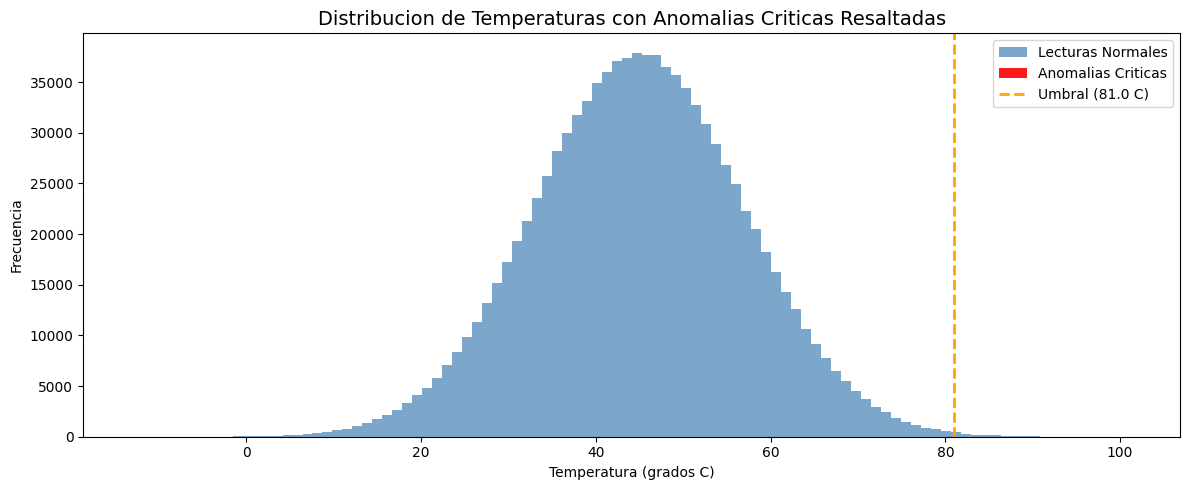

In [39]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(datos_temperatura, bins=100, color='steelblue', alpha=0.7, label='Lecturas Normales')
ax.hist(anomalias_extraidas, bins=20, color='red', alpha=0.9, label='Anomalias Criticas')
ax.axvline(UMBRAL_SEVERIDAD, color='orange', linestyle='--', linewidth=2,
           label=f'Umbral ({UMBRAL_SEVERIDAD:.1f} C)')

ax.set_title('Distribucion de Temperaturas con Anomalias Criticas Resaltadas', fontsize=14)
ax.set_xlabel('Temperatura (grados C)')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()


---
## PARTE 3: Limpieza e Imputacion de Datos

__Objetivo:__ Los registros con codigo de estado `3` (Averiado/Perdido) deben ser reemplazados con un valor estadisticamente valido para no sesgar el analisis. Usaremos la **mediana** de los datos validos, ya que es robusta frente a valores extremos.

---

La funcion `np.where()` permite el reemplazo condicional:
```
np.where(Condicion, Valor_si_Verdadero, Valor_si_Falso)
```


In [40]:
# Mascara para datos validos (estado distinto de 3)
mascara_datos_validos = (codigos_estado != 3)

# Calcular la mediana solo sobre datos validos
mediana_temp_validos = np.median(datos_temperatura[mascara_datos_validos])
print(f'Mediana de lecturas validas: {mediana_temp_validos:.2f} grados C')


Mediana de lecturas validas: 44.99 grados C


In [41]:
# Reemplazar lecturas defectuosas con la mediana usando np.where()
datos_temp_limpios = np.where(
    mascara_datos_validos,   # CONDICION: lectura defectuosa?
    datos_temperatura,  # SI: reemplazar con la mediana
    mediana_temp_validos      # NO: conservar valor original
)

cantidad_imputados = (codigos_estado == 3).sum() #también se puede simplificar la máscara booleana
print(f'Total de lecturas defectuosas imputadas: {cantidad_imputados}')


Total de lecturas defectuosas imputadas: 20102


In [ ]:
# Verificar que la limpieza no altera la distribucion
print(f'Mediana Original: {np.median(datos_temperatura):.2f} grados C')
print(f'Mediana Limpia:   {np.median(datos_temp_limpios):.2f} grados C')


Mediana Original: 44.99 grados C
Mediana Limpia:   44.99 grados C


Incluso despues de limpiar mas de 20.000 registros defectuosos, la mediana de temperatura se mantuvo estable en **44,99 C**. Eso indica que el dataset es estadisticamente solido y que el reemplazo no altero la distribucion general.


---
## PARTE 4: Conclusión

El `ndarray` de NumPy es el motor silencioso de todo el ecosistema de ciencia de datos de Python. Cada libreria importante como **Pandas**, **scikit-learn**, **TensorFlow** y **PyTorch** utiliza arrays de NumPy en su nucleo para la computacion numerica rapida.

En este proyecto hemos demostrado:
- Calculo instantaneo de estadisticas sobre **1 millon de registros**
- Deteccion de **34 anomalias criticas** entre 1 millon de lecturas en milisegundos
- Imputacion de **20.102 registros defectuosos** sin distorsionar la distribucion

El siguiente paso logico es pasar al analisis estructurado con la libreria **Pandas**, que organiza los arrays de NumPy en DataFrames para un etiquetado y manipulacion aun mas sencillos.

---
